# Datasets with Derivable Token Counts

In [1]:
import pandas as pd
from pathlib import Path
from datasets import load_from_disk

BASE_DIR = Path(".")

#

## **WildChat-1M (NAACL 2024)**
These contain real-world user-ChatGPT conversations (collected with user consent). Each **entry** in the dataset is an actual conversation between one user and ChatGPT.

In [2]:
wildchat = load_from_disk(str(BASE_DIR / "wildchat"))
wildchat

DatasetDict({
    train: Dataset({
        features: ['conversation_hash', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted', 'state', 'country', 'hashed_ip', 'header'],
        num_rows: 837989
    })
})

In [ ]:
# convert the dataset to a pandas dataframe
df_wildchat = wildchat['train'].to_pandas()
df_wildchat.head()

# execution time ~ 2 min

,conversation_hash,model,timestamp,conversation,turn,language,openai_moderation,detoxify_moderation,toxic,redacted,state,country,hashed_ip,header
0,c9ec5b440fbdd2a269333dd241f32f64,gpt-4-0314,2023-04-09 00:02:53+00:00,[{'content': 'Hey there! Are you familiar with...,1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.00020589135237969458, '...",False,False,Texas,United States,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,"{'accept-language': 'en-US,en;q=0.9,es;q=0.8',..."
1,34f1581760df304d539e2fe4653b40d3,gpt-4-0314,2023-04-09 00:03:20+00:00,[{'content': 'Crea una imagen de una mujer cor...,2,Spanish,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.007170863449573517, 'in...",False,False,A Coruña,Spain,58369722cd0bdf7fc027a67491ba65b74576df6994c36c...,"{'accept-language': 'es-ES,es;q=0.9,en;q=0.8',..."
2,cf1267ca6b2f6fccc9c36652a00059a1,gpt-4-0314,2023-04-09 00:04:52+00:00,"[{'content': 'Old age PT hx of DM, HTN, dyslip...",1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.0002258022577734664, 'i...",False,False,Mecca Region,Saudi Arabia,8133108d1c433c180c6be8302dc5a6681f2bec980190a1...,"{'accept-language': 'en-US,en;q=0.9', 'user-ag..."
3,7f1c97a4f873cda8106b010d040be078,gpt-4-0314,2023-04-09 00:06:29+00:00,[{'content': 'calcula la mediana de followers:...,1,Catalan,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.0003390185011085123, 'i...",False,False,Barcelona,Spain,846e43fb5fbb4b8cfbafa17083387aad62e58f5fb23482...,"{'accept-language': 'es,es-ES;q=0.9,en;q=0.8,e..."
4,e98d3e74c57f9a65261df393d9124ac2,gpt-4-0314,2023-04-09 00:06:49+00:00,[{'content': 'Hey there! Are you familiar with...,1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.00020642601884901524, '...",False,False,Texas,United States,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,"{'accept-language': 'en-US,en;q=0.9,es;q=0.8',..."


#

### **Metadata Fields**

| Field                 | Meaning                                                                                                                                                                                                                                                                                                                    |
| --------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `conversation_hash`   | Hash of the conversation content. It is **not a unique ID**: identical-content conversations share the same hash. For unique per-turn identification, use `turn_identifier` inside each turn. ([Hugging Face][1])                                                                                                          |
| `model`               | The OpenAI model used for the conversation, for example `gpt-3.5-turbo`, `gpt-4`, etc. ([Hugging Face][1])                                                                                                                                                                                                                 |
| `timestamp`           | UTC timestamp of the **last turn** in the conversation. ([Hugging Face][1])                                                                                                                                                                                                                                                |
| `conversation`        | List of utterances/messages, alternating user and assistant turns. Each item is a dictionary containing message-level metadata. ([Hugging Face][1])                                                                                                                                                                        |
| `turn`                | Number of user-assistant interaction rounds in the conversation. A “turn” means one round of user input plus assistant response. ([Hugging Face][1])                                                                                                                                                                       |
| `language`            | Conversation-level language: the most frequently detected language among utterances in that conversation. ([Hugging Face][1])                                                                                                                                                                                              |
| `openai_moderation`   | List of OpenAI Moderation API results, one element per utterance. Empty utterances get an empty dictionary. ([Hugging Face][1])                                                                                                                                                                                            |
| `detoxify_moderation` | List of Detoxify toxicity scores, one element per utterance. Empty utterances get an empty dictionary. ([Hugging Face][1])                                                                                                                                                                                                 |
| `toxic`               | Conversation-level boolean: `true` if any utterance was considered toxic by OpenAI Moderation or Detoxify. Public non-toxic releases should generally have this as `false`. ([Hugging Face][1])                                                                                                                            |
| `redacted`            | Conversation-level boolean: `true` if PII was detected and anonymized. In 4.8M, the card says this also covers API secrets. ([Hugging Face][1])                                                                                                                                                                            |
| `state`               | State/region inferred from the most common IP address in the conversation. Can be `None` if GeoIP2 cannot identify it. ([Hugging Face][1])                                                                                                                                                                                 |
| `country`             | Country inferred from the most common IP address in the conversation. Can be `None` if GeoIP2 cannot identify it. ([Hugging Face][1])                                                                                                                                                                                      |
| `hashed_ip`           | Most common hashed IP address in the conversation. This is not the raw IP, but it can still be used for linkage analysis. ([Hugging Face][1])                                                                                                                                                                              |
| `header`              | Request header information, including operating system, browser/version, and accepted languages. The dataset card notes this can help link multiple conversations when used with `hashed_ip`; every turn in a conversation has the same header because this was used to link turns into conversations. ([Hugging Face][1]) |

**Note**: The timestamp is not very intersting as it is only for the last turn.

### **Fields in `conversation`**
| Field             | Meaning                                                                                                                             |
| ----------------- | ----------------------------------------------------------------------------------------------------------------------------------- |
| `role`            | Speaker role: usually `user` or `assistant`.                                                                                        |
| `content`         | Text of that utterance.                                                                                                             |
| `language`        | Detected language of that utterance.                                                                                                |
| `toxic`           | Utterance-level toxicity flag.                                                                                                      |
| `redacted`        | Utterance-level flag indicating whether PII, and in 4.8M also secrets, were detected and anonymized.                                |
| `turn_identifier` | Unique identifier for the individual turn. Use this when you need a unique key rather than `conversation_hash`. ([Hugging Face][1]) |

For **user turns** (i.e., where `role` is `user`), there are additional fields:

| Field       | Meaning                                             |
| ----------- | --------------------------------------------------- |
| `hashed_ip` | Hashed IP address associated with that user turn.   |
| `state`     | State/region inferred from the original IP address. |
| `country`   | Country inferred from the original IP address.      |
| `header`    | Request headers for that turn.                      |

For **assistant turns** (i.e., where `role` is `assistant`), there are additional fields:

| Field       | Meaning                                             |
| ----------- | --------------------------------------------------- |
| `model`     | Model used for generating that assistant turn.      |
| `prompt`    | Prompt used for generating that assistant turn.     |

[1]: https://huggingface.co/datasets/allenai/WildChat-4.8M "allenai/WildChat-4.8M · Datasets at Hugging Face"

In [4]:
def print_conversation_details(conversation, print_metadata=True):
    for turn in conversation:
        print(f"Turn Identifier: {turn['turn_identifier']}")
        print(f"Role: {turn['role']}")
        print(f"Content: {turn['content']}")
        if print_metadata:
            print("-" * 20)
            print("Other Metadata:")
            for k, v in turn.items():
                if k not in ['turn_identifier', 'role', 'content']:
                    print(f"{k}: {v}")
        print("*" * 80)

In [5]:
print_conversation_details(df_wildchat.iloc[0]['conversation'])

Turn Identifier: 101001
Role: user
Content: Hey there! Are you familiar with reality shifting? So, I’m refining a foolproof method for reality shifting and want to pick a destination. Want to help me? I’m thinking something pretty personalized. There are a few things that are required of my destination. 1. The quest. I have to have a clear overarching goal in my reality, and don’t make it too crazy. It should be more along the lines of “save the president’s daughter” or “escape this weird wacky sinister place” NOT “get an artifact that literally controls reality”. Seriously, don’t make me fetch an artifact, or fetch anything. Instead, make me DO something. 2. Babes. I need pretty girls. 3. The entry. I need to get to lose consciousness in order to begin my journey in my desired reality, preferably by having it knocked out by one of the aforementioned babes. 4. Action. It needs to be cool. 5. Unconsciousness. Myself and the babes need to pass out in this place, preferably by being knock

#

In [6]:
# used models in the dataset
print("Unique models used in the dataset:")
print(df_wildchat['model'].unique())

Unique models used in the dataset:
<ArrowStringArray>
[        'gpt-4-0314', 'gpt-3.5-turbo-0301', 'gpt-3.5-turbo-0613',
 'gpt-4-1106-preview',         'gpt-4-0613', 'gpt-3.5-turbo-0125',
 'gpt-4-0125-preview']
Length: 7, dtype: str


The models appear to be mostly `gpt-3.5-turbo` and `gpt-4`, with some specific sub-versions.

*What is the appropriate **tokenizer** to be used?*

| WildChat `model`                          | Tokenizer / encoding to use                    |
| ----------------------------------------- | ---------------------------------------------- |
| `gpt-3.5-turbo`                           | `tiktoken.encoding_for_model("gpt-3.5-turbo")` |
| `gpt-4`                                   | `tiktoken.encoding_for_model("gpt-4")`         |
| older/ambiguous GPT-3.5 or GPT-4 variants | usually `cl100k_base`, via `tiktoken`          |

We want be able to get back the exact token numbers as per OpenAI's token counting. **Note** for example that OpenAI *warns* that chat messages have model-specific **formatting overhead**!

Getting the number of tokens is as simple as:

```python
import tiktoken

enc = tiktoken.encoding_for_model("gpt-4")  # or row["model"]
output_tokens = len(enc.encode(assistant_message["content"]))
input_tokens = len(enc.encode(user_message["content"]))
```

#

### Preliminary (non-token) analysis

In [7]:
import matplotlib.pyplot as plt

def histogram_of_counts(counts, x_label, y_label, title, log_scale=False):

    plt.figure(figsize=(14, 3))
    plt.bar(counts.index, counts.values)
    plt.yscale('log')  # Use logarithmic scale for better visibility of smaller counts
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.show()

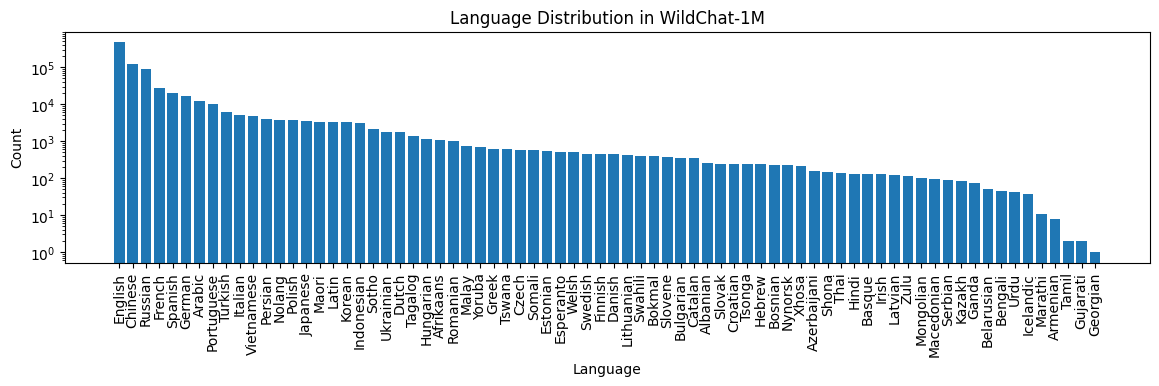

In [8]:
# histogram of the languages used in the conversations
language_counts = df_wildchat['language'].value_counts()

histogram_of_counts(language_counts, x_label='Language', y_label='Count', title='Language Distribution in WildChat-1M', log_scale=True)

**Note** that English, Chinese and Russian are order of magnitude more common than other languages in the dataset. 

In [9]:
df_wildchat.columns

Index(['conversation_hash', 'model', 'timestamp', 'conversation', 'turn',
       'language', 'openai_moderation', 'detoxify_moderation', 'toxic',
       'redacted', 'state', 'country', 'hashed_ip', 'header'],
      dtype='str')

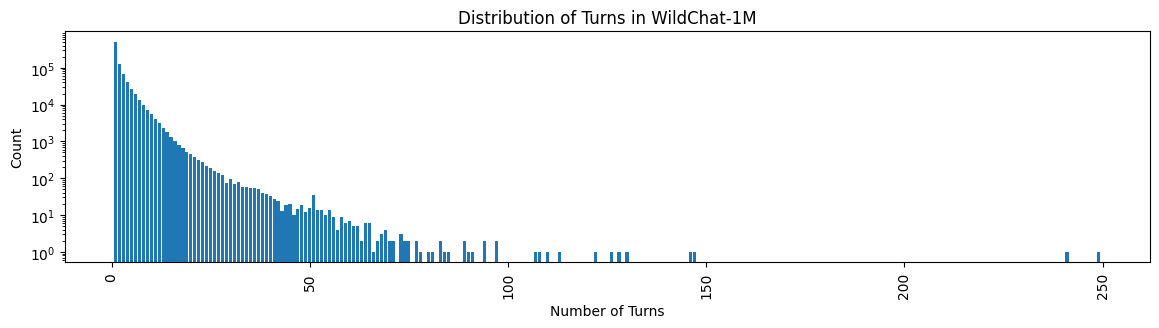

In [10]:
# let's see also the distribution of the number of turns in the conversations
turn_counts = df_wildchat['turn'].value_counts()

histogram_of_counts(turn_counts, x_label='Number of Turns', y_label='Count', title='Distribution of Turns in WildChat-1M', log_scale=True)

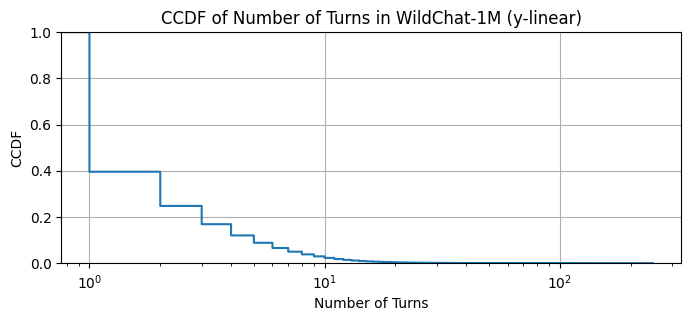

In [11]:
# plot the ccdf of the number of turns in the conversations (using seaborn for the ecdf plot)
import seaborn as sns

plt.figure(figsize=(8, 3))
sns.ecdfplot(df_wildchat['turn'], complementary=True)
plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Number of Turns')
plt.ylabel('CCDF')
plt.title('CCDF of Number of Turns in WildChat-1M (y-linear)')
plt.grid()


60% of conversation are just 1 turn, and another roughly 20% are 2 turns. The distribution of turns is very long-tailed, with some conversations having 100+ turns.

### **Token-level analysis**

In [12]:
import tiktoken
import numpy as np
from functools import lru_cache
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    context="talk",
    style="ticks",
    palette="deep",
    font="sans-serif",
    color_codes=True,
    font_scale=1.1,
    rc={
        "figure.facecolor": "white",
        "font.family": "sans-serif",
        "axes.labelpad": 12,
        "legend.fontsize": 12,
        "lines.linewidth": 1.2,
        "grid.linestyle": "--",
    },
)

@lru_cache(maxsize=16)
def get_encoder(model_name):
    try:
        return tiktoken.encoding_for_model(model_name)
    except KeyError:
        return tiktoken.get_encoding("cl100k_base")

def count_tokens(enc, text):
    # disallowed_special=() treats special token strings (e.g. <|endoftext|>) as plain text,
    # which is correct for user-generated content that may contain them literally.
    return len(enc.encode(text, disallowed_special=()))

def model_family(model_name):
    if model_name.startswith("gpt-4"):
        return "GPT-4"
    elif model_name.startswith("gpt-3.5"):
        return "GPT-3.5-turbo"
    return "Other"

def extract_requests(row):
    """
    Treats each user/assistant turn pair as one LLM inference request.

    - context_tokens : full conversation history up to and including the user message
                       (what the model actually receives as input)
    - prompt_tokens  : just the standalone current user message (no history)
    - output_tokens  : assistant response token count
    """
    conversation = row["conversation"]
    model = row["model"]
    enc = get_encoder(model)

    requests = []
    context_messages = []
    i = 0
    turn_idx = 0

    while i < len(conversation):
        msg = conversation[i]
        if msg["role"] != "user":
            i += 1
            continue

        user_content = msg.get("content") or ""
        prompt_tokens = count_tokens(enc, user_content)

        output_tokens = 0
        if i + 1 < len(conversation) and conversation[i + 1]["role"] == "assistant":
            asst_content = conversation[i + 1].get("content") or ""
            output_tokens = count_tokens(enc, asst_content)

        # context = all previous messages concatenated + current user message
        context_text = "\n".join((m.get("content") or "") for m in context_messages) + "\n" + user_content
        context_tokens = count_tokens(enc, context_text)

        requests.append({
            "context_tokens": context_tokens,
            "prompt_tokens": prompt_tokens,
            "output_tokens": output_tokens,
            "model_family": model_family(model),
            "language": row["language"],
            "turn_number": turn_idx + 1,
            "conversation_n_turns": row["turn"],
        })

        context_messages.append(msg)
        if i + 1 < len(conversation) and conversation[i + 1]["role"] == "assistant":
            context_messages.append(conversation[i + 1])
            i += 2
        else:
            i += 1
        turn_idx += 1

    return requests

In [13]:
CACHE = BASE_DIR / "_cache"
CACHE.mkdir(exist_ok=True)
    
if (CACHE / "wildchat_requests.parquet").exists():
    df_req = pd.read_parquet(CACHE / "wildchat_requests.parquet")
else:
    all_requests = []
    for _, row in tqdm(df_wildchat.iterrows(), total=len(df_wildchat), desc="Tokenizing WildChat"):
        all_requests.extend(extract_requests(row))

    df_req = pd.DataFrame(all_requests)
    print(f"Total requests (turns): {len(df_req):,}")

    # make a cache folder if it doesn't exist
    df_req.to_parquet(CACHE / "wildchat_requests.parquet", index=False)

df_req.head()

# execution time: 40-45 min (if not cached)

,context_tokens,prompt_tokens,output_tokens,model_family,language,turn_number,conversation_n_turns
0,308,307,650,GPT-4,English,1,1
1,17,16,209,GPT-4,Spanish,1,2
2,249,24,257,GPT-4,Spanish,2,2
3,38,37,69,GPT-4,English,1,1
4,77,76,176,GPT-4,Catalan,1,1


**Note**: Here we have a lot of information at the session level, because we have the total `context_tokens` for each turn, and also the `prompt_tokens` for the user message and the `output_tokens` for the assistant message. So it is clear that at each turn the `context_tokens` is the sum of the `prompt_tokens` and the `output_tokens` from the previous turn, plus the new `prompt_tokens` from the current turn.

#

In [14]:
# Summary statistics: prompt_tokens (standalone user msg), context_tokens (full input to model), output_tokens

# read cached requests if needed
df_req = pd.read_parquet(CACHE / "wildchat_requests.parquet")

rows = []
for col, label in [
    ("prompt_tokens",   "Prompt tokens (user msg only)"),
    ("context_tokens",  "Context tokens (full input to model)"),
    ("output_tokens",   "Output tokens (assistant response)"),
]:
    s = df_req[col].dropna()
    rows.append({
        "Metric": label,
        "Mean": f"{s.mean():.0f}",
        "p50":  f"{s.quantile(0.50):.0f}",
        "p90":  f"{s.quantile(0.90):.0f}",
        "p95":  f"{s.quantile(0.95):.0f}",
        "p99":  f"{s.quantile(0.99):.0f}",
        "Max":  f"{int(s.max())}",
    })

pd.DataFrame(rows).set_index("Metric")

,Mean,p50,p90,p95,p99,Max
Metric,,,,,,
Prompt tokens (user msg only),247,28,685,858,3133,123628
Context tokens (full input to model),1500,547,3196,5081,17672,127725
Output tokens (assistant response),400,336,820,1005,1546,4175


#### Token length distributions

Three views of "input length":
- **Prompt tokens**: the standalone user message in isolation — what matters for single-turn characterization
- **Context tokens**: the full conversation history seen by the model at each turn — what matters for KV-cache and prefill cost
- **Output tokens**: the assistant response — what drives decode cost

C:\Users\localadmin\AppData\Local\Temp\ipykernel_45160\809296089.py:35: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\localadmin\.venvs\llm-vidur\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


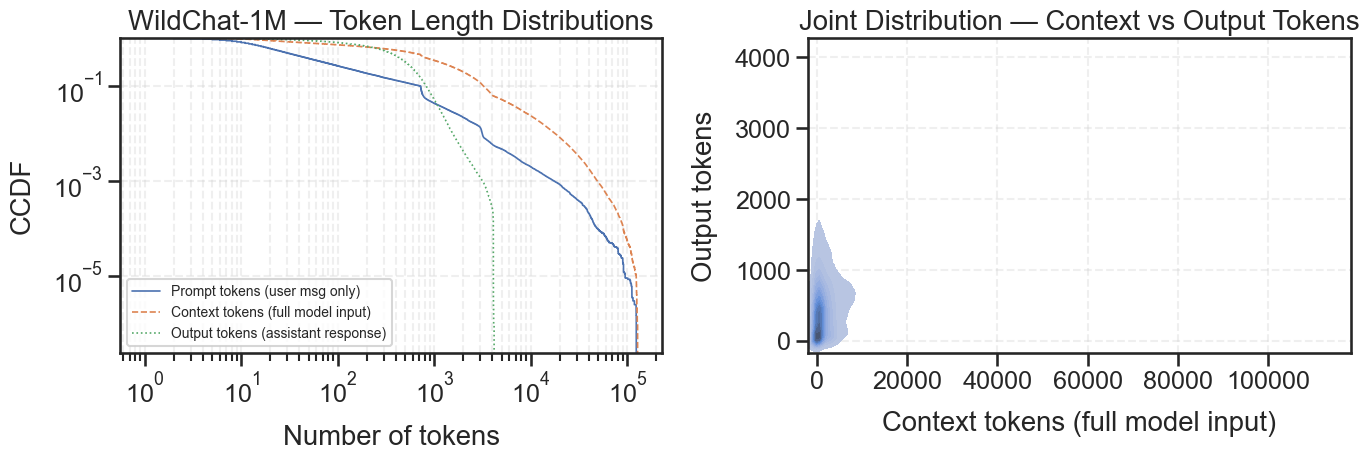

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CCDF of all three token length views
ax = axes[0]
for col, label, ls in [
    ("prompt_tokens",  "Prompt tokens (user msg only)",     "-"),
    ("context_tokens", "Context tokens (full model input)", "--"),
    ("output_tokens",  "Output tokens (assistant response)", ":"),
]:
    sns.ecdfplot(data=df_req, x=col, complementary=True, ax=ax, label=label, linestyle=ls)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of tokens")
ax.set_ylabel("CCDF")
ax.set_title("WildChat-1M — Token Length Distributions")
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)

# Right: joint distribution of context_tokens vs output_tokens (inference perspective)
ax2 = axes[1]
sns.kdeplot(
    data=df_req.sample(min(50_000, len(df_req)), random_state=42),
    x="context_tokens",
    y="output_tokens",
    fill=True,
    levels=15,
    thresh=0.05,
    ax=ax2,
)
ax2.set_xlabel("Context tokens (full model input)")
ax2.set_ylabel("Output tokens")
ax2.set_title("Joint Distribution — Context vs Output Tokens")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Output-to-input token ratio

Values < 1 → prefill-heavy (large context, short answer). Values > 1 → decode-heavy (short prompt, long generation).
Note: using `context_tokens` as the denominator, since that's the actual input size the model sees.

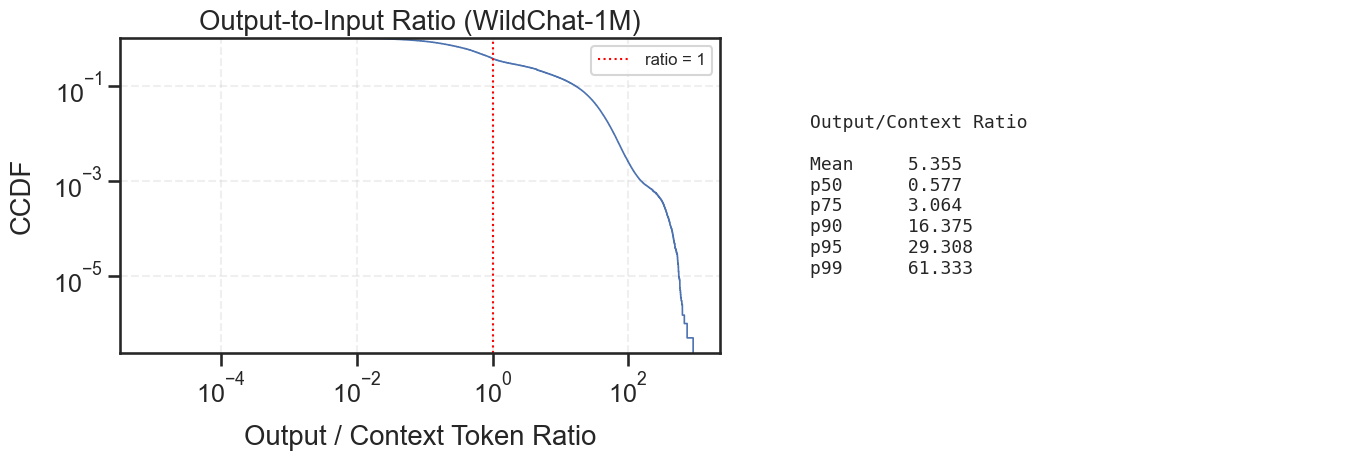

In [16]:
ratio = (df_req["output_tokens"] / df_req["context_tokens"]).replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CCDF of output/context ratio
sns.ecdfplot(x=ratio, complementary=True, ax=axes[0])
axes[0].axvline(1.0, color="red", linestyle=":", linewidth=1.5, label="ratio = 1")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Output / Context Token Ratio")
axes[0].set_ylabel("CCDF")
axes[0].set_title("Output-to-Input Ratio (WildChat-1M)")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

# Summary stats printed
stats = {
    "Mean": ratio.mean(),
    "p50":  ratio.quantile(0.50),
    "p75":  ratio.quantile(0.75),
    "p90":  ratio.quantile(0.90),
    "p95":  ratio.quantile(0.95),
    "p99":  ratio.quantile(0.99),
}
axes[1].axis("off")
text = "\n".join(f"{k:<8} {v:.3f}" for k, v in stats.items())
axes[1].text(0.1, 0.5, f"Output/Context Ratio\n\n{text}",
             fontfamily="monospace", fontsize=13, va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

#### Breakdown by model family (GPT-3.5 vs GPT-4)

GPT-4 users may behave differently — longer prompts, more complex tasks, more turns.

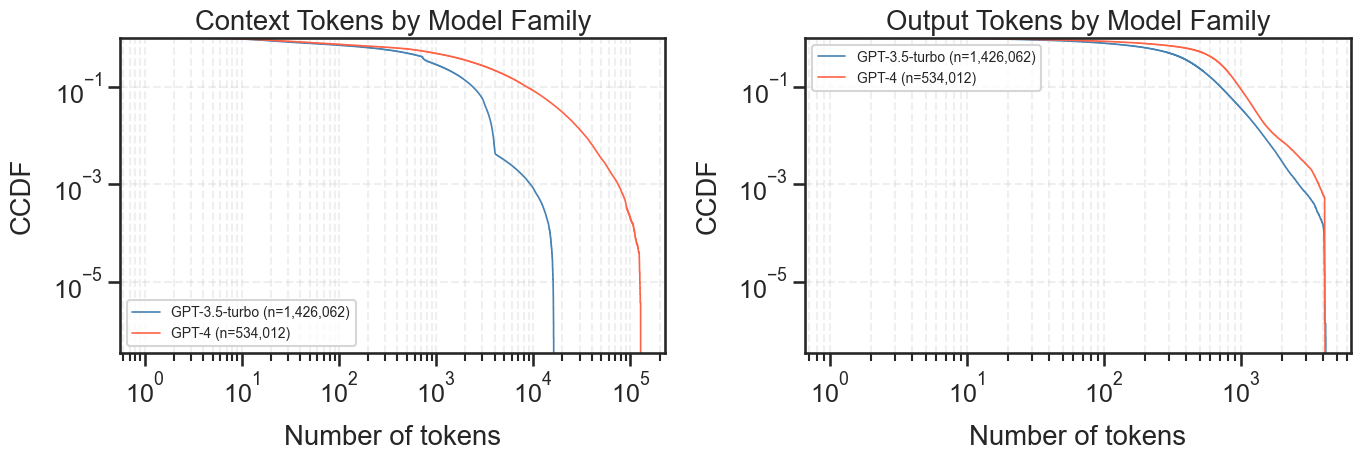

context_tokens        output_tokens       
                        mean median          mean median
model_family                                            
GPT-3.5-turbo          834.0  468.0         350.0  292.0
GPT-4                 3278.0  895.0         535.0  522.0

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_model = {"GPT-3.5-turbo": "steelblue", "GPT-4": "tomato"}

for ax, col, title in [
    (axes[0], "context_tokens", "Context Tokens by Model Family"),
    (axes[1], "output_tokens",  "Output Tokens by Model Family"),
]:
    for family, grp in df_req.groupby("model_family"):
        sns.ecdfplot(data=grp, x=col, complementary=True, ax=ax,
                     label=f"{family} (n={len(grp):,})", color=palette_model.get(family))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of tokens")
    ax.set_ylabel("CCDF")
    ax.set_title(title)
    ax.legend(fontsize=10)
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# Quick stats comparison
df_req.groupby("model_family")[["context_tokens", "output_tokens"]].agg(["mean", "median"]).round(0)

#### Multi-turn context growth

In multi-turn conversations, the input context grows with each turn because the full conversation history is prepended. This is a key driver of KV-cache pressure — the effective input size can be orders of magnitude larger than the first user message alone.

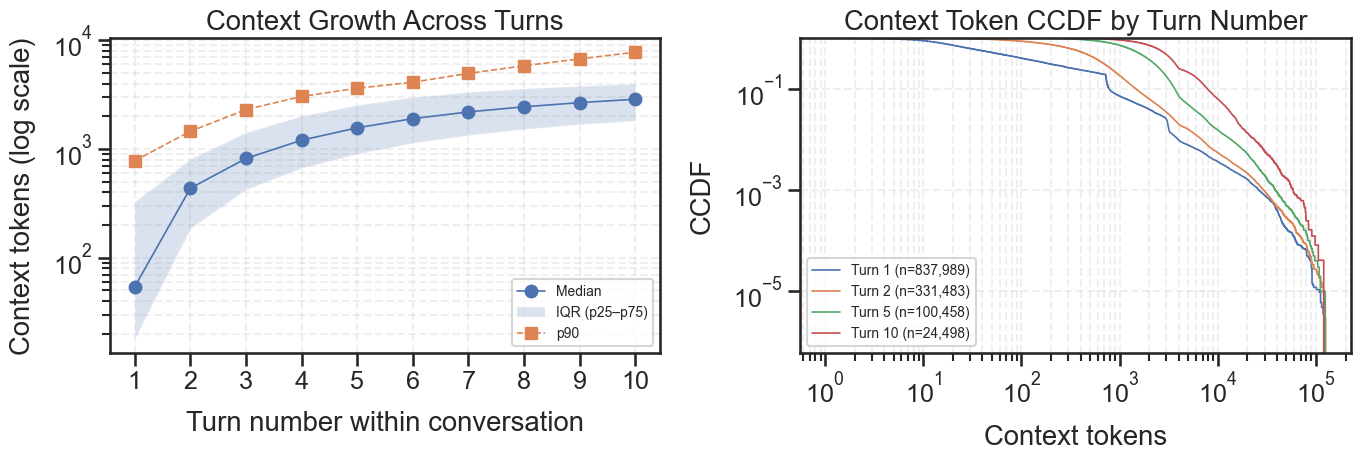

In [18]:
# Only look at turns 1-10 (long-tail turns have tiny sample sizes)
MAX_TURN = 10
df_mt = df_req[df_req["turn_number"] <= MAX_TURN].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: median and p90 context_tokens by turn number
agg = df_mt.groupby("turn_number")["context_tokens"].agg(
    median="median", p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75), p90=lambda x: x.quantile(0.90)
)
ax = axes[0]
ax.plot(agg.index, agg["median"], marker="o", label="Median")
ax.fill_between(agg.index, agg["p25"], agg["p75"], alpha=0.2, label="IQR (p25–p75)")
ax.plot(agg.index, agg["p90"], marker="s", linestyle="--", label="p90")
ax.set_yscale("log")
ax.set_xlabel("Turn number within conversation")
ax.set_ylabel("Context tokens (log scale)")
ax.set_title("Context Growth Across Turns")
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
ax.set_xticks(range(1, MAX_TURN + 1))

# Right: CCDF of context_tokens for turn 1, 2, 5, 10
ax2 = axes[1]
for t, color in [(1, "C0"), (2, "C1"), (5, "C2"), (10, "C3")]:
    sub = df_req[df_req["turn_number"] == t]
    if len(sub) < 100:
        continue
    sns.ecdfplot(data=sub, x="context_tokens", complementary=True, ax=ax2,
                 label=f"Turn {t} (n={len(sub):,})", color=color)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Context tokens")
ax2.set_ylabel("CCDF")
ax2.set_title("Context Token CCDF by Turn Number")
ax2.legend(fontsize=10)
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

#### Token distribution by language

Top-5 languages by request volume. Different languages may have very different token efficiencies (e.g., CJK characters tokenize into more tokens per character with `cl100k_base`).

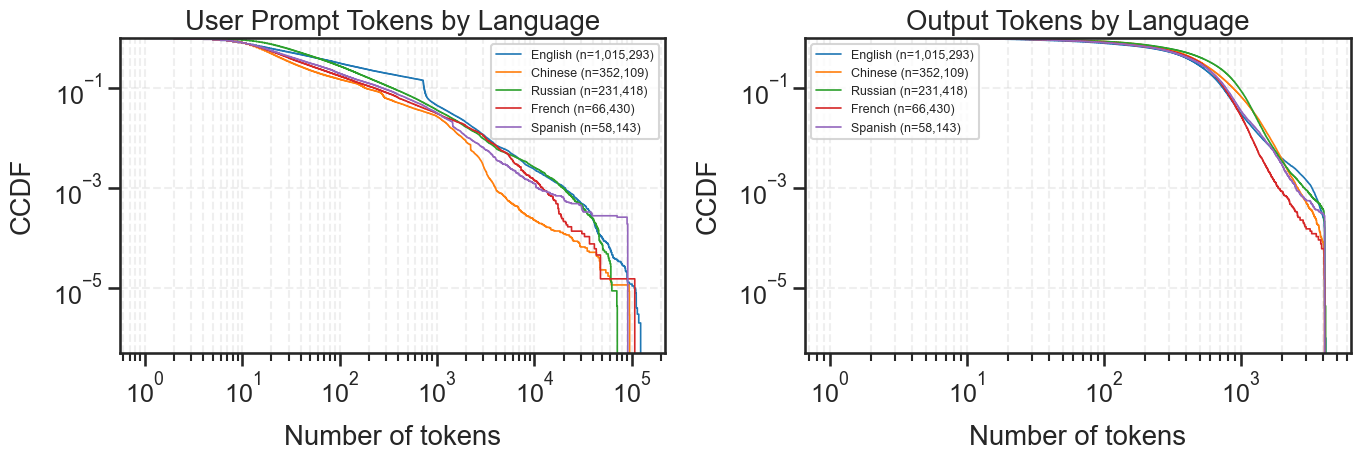

,prompt_tokens,output_tokens
language,,
Russian,41.0,407.0
English,33.0,319.0
Spanish,24.0,327.0
French,22.0,343.0
Chinese,19.0,359.0


In [19]:
top_langs = df_req["language"].value_counts().head(5).index.tolist()
palette_lang = dict(zip(top_langs, sns.color_palette("tab10", n_colors=len(top_langs))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], "prompt_tokens",  "User Prompt Tokens by Language"),
    (axes[1], "output_tokens",  "Output Tokens by Language"),
]:
    for lang in top_langs:
        sub = df_req[df_req["language"] == lang]
        sns.ecdfplot(data=sub, x=col, complementary=True, ax=ax,
                     label=f"{lang} (n={len(sub):,})", color=palette_lang[lang])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of tokens")
    ax.set_ylabel("CCDF")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# median prompt and output tokens by language
df_req[df_req["language"].isin(top_langs)].groupby("language")[["prompt_tokens", "output_tokens"]].median().round(0).sort_values("prompt_tokens", ascending=False)

#### Arrival process

WildChat timestamps record only the **last turn** of each conversation, so we have one timestamp per conversation — not per turn. This gives us a coarse-grained but still useful view of the macro arrival process.

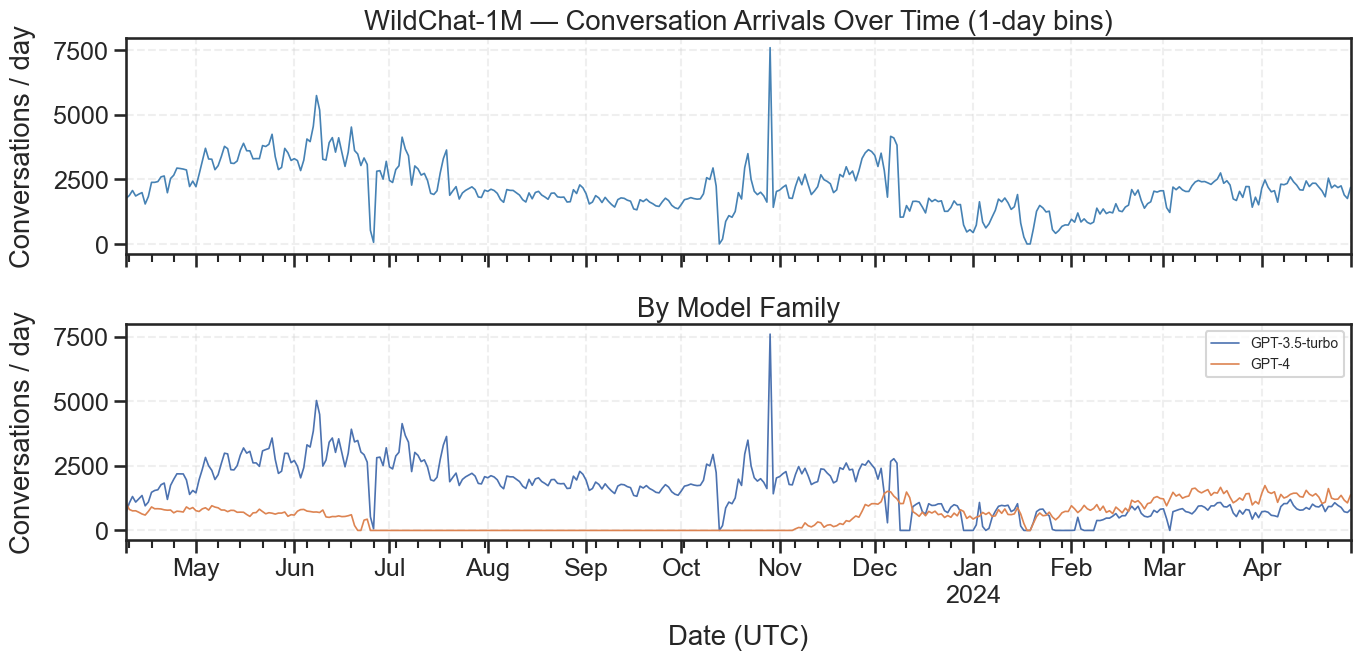

Daily arrival counts — Mean: 2165.3, Variance: 868157.8, Fano factor: 400.93
(Fano ≈ 1 → Poisson; >> 1 → over-dispersed / bursty)


In [20]:
df_ts = df_wildchat.copy()
df_ts["timestamp"] = pd.to_datetime(df_ts["timestamp"], utc=True)
df_ts = df_ts.dropna(subset=["timestamp"]).sort_values("timestamp")

RESAMPLE = "1D"  # daily counts — coarse but interpretable given we only have last-turn ts

counts = df_ts.set_index("timestamp").resample(RESAMPLE).size()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

counts.plot(ax=axes[0], marker="", color="steelblue")
axes[0].set_title("WildChat-1M — Conversation Arrivals Over Time (1-day bins)")
axes[0].set_ylabel("Conversations / day")
axes[0].grid(True, alpha=0.3)

# breakdown by model family
for model, grp in df_ts.groupby(df_ts["model"].apply(model_family)):
    g_counts = grp.set_index("timestamp").resample(RESAMPLE).size()
    g_counts.plot(ax=axes[1], label=model, marker="")

axes[1].set_title("By Model Family")
axes[1].set_ylabel("Conversations / day")
axes[1].set_xlabel("Date (UTC)")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Fano factor on daily counts
mean_c, var_c = counts.mean(), counts.var()
print(f"Daily arrival counts — Mean: {mean_c:.1f}, Variance: {var_c:.1f}, Fano factor: {var_c/mean_c:.2f}")
print("(Fano ≈ 1 → Poisson; >> 1 → over-dispersed / bursty)")

#### Additional analyses possible with WildChat text content

Because WildChat provides the **raw conversation text** (unlike Azure/BurstGPT which are token-count-only), several text-level characterizations become possible:

| Analysis | What it reveals | How to do it |
|---|---|---|
| **Conversation topic clustering** | What tasks do users actually bring to ChatGPT? Coding, creative writing, translation, Q&A, etc. | Embed a sample with a small sentence encoder (e.g. `sentence-transformers/all-MiniLM-L6-v2`), then k-means or UMAP+HDBSCAN |
| **Token efficiency by language** | CJK and Cyrillic scripts are notoriously under-tokenized by `cl100k_base` — more tokens per semantic unit than English | Compare `prompt_tokens / word_count` across languages |
| **Prompt complexity proxies** | Long prompts ≠ complex prompts. Measure question depth via number of sentences, presence of code fences, explicit instructions count | Simple regex / spaCy pipeline |
| **Response verbosity by task type** | Does the model produce longer outputs for creative tasks vs. factual Q&A? | Group by detected topic, compare `output_tokens` |
| **Context re-use patterns in multi-turn** | How much of the growing context is "new" information vs. repeated prior exchanges? | Compute incremental token delta: `context_tokens[k] - context_tokens[k-1]` and compare to `output_tokens[k-1]` |
| **User editing behavior** | Do users send very short follow-ups ("ok", "continue", "more") vs. long rephrases? | Histogram of `prompt_tokens` conditioned on `turn_number > 1` |
| **Toxicity vs. token length** | Are toxic requests shorter or longer? | Compare `prompt_tokens` for `toxic=True` vs `False` rows |
| **Country-level request patterns** | Do users from different regions submit longer prompts or get longer responses? | Group by `country`, compute median token counts |

#

#

#

#

## **LMSYS-Chat-1M (ICLR 2024)**

In [ ]:
lmsys = load_from_disk(str(BASE_DIR / "lmsys_chat_1m"))
lmsys

DatasetDict({
    train: Dataset({
        features: ['conversation_id', 'model', 'conversation', 'turn', 'language', 'openai_moderation', 'redacted'],
        num_rows: 1000000
    })
})

#

#

## **ShareChat (arXiv:2512.17843)**

In [ ]:
sharechat_dir = BASE_DIR / "sharechat"
sharechat = {
    platform: pd.read_csv(sharechat_dir / f"{platform}_results_final_language_filtered.csv")
    for platform in ["chatgpt", "claude", "gemini", "grok", "perplexity"]
}

sharechat["chatgpt"].head()

,platform,url,turns_count,message_index,role,plain_text,model,message_create_time,create_time,detected_language_final,topic
0,chatgpt,https://chatgpt.com/share/67712f8d-7900-800e-b...,1,1,user,Lorca Planes. <REDACTED> vacunación. <REDACTED...,default_model_slug,ts:1735470944.298904,2024-12-29 06:16:29,Spanish,specific_info
1,chatgpt,https://chatgpt.com/share/67712f8d-7900-800e-b...,1,2,llm,"En enero de 2021, <REDACTED>, <REDACTED>, reci...",default_model_slug,ts:1735470952.661828,2024-12-29 06:16:29,Spanish,NaN
2,chatgpt,https://chatgpt.com/share/67770737-9244-8006-9...,8,1,user,What common words of any length can I make fro...,default_model_slug,ts:1735853731.048237,2025-01-02 16:37:59,English,mathematical_calculation
3,chatgpt,https://chatgpt.com/share/67770737-9244-8006-9...,8,2,llm,Please provide the letters you would like me t...,default_model_slug,ts:1735853732.094700,2025-01-02 16:37:59,English,NaN
4,chatgpt,https://chatgpt.com/share/67770737-9244-8006-9...,8,3,user,e r t u I o c n a s d h,default_model_slug,ts:1735853762.876241,2025-01-02 16:37:59,English,unclear
